In [1]:
%matplotlib inline

# scientific computing and plotting
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
import random
from scipy import stats 

# HDDM related packages
import pymc as pm
import hddm
import kabuki
import arviz as az
print("The current HDDM version: ", hddm.__version__)
print("The current kabuki version is: ", kabuki.__version__)
print("The current PyMC version is: ", pm.__version__)
print("The current ArviZ version is: ", az.__version__)

The current HDDM version:  1.0.1RC
The current kabuki version is:  0.6.5RC4
The current PyMC version is:  2.3.8
The current ArviZ version is:  0.15.1


In [2]:
#load model
hddm_val_acc = hddm.load('hddm_val_m0_acc.hddm')
hddm_val_choice = hddm.load('hddm_val_m1_choice.hddm')
Stim_zflip = hddm.load('hddmStim_zflip_m1.hddm')
Stim_vflip = hddm.load('hddmStim_vflip_m1.hddm')
Reg_val_acc = hddm.load('hddmReg_val_m0_acc.hddm')
Reg_val_choice = hddm.load('hddmReg_val_m2_choice.hddm')
Reg_vflip_coef = hddm.load('hddmReg_stim_vflip_m2.hddm')
Reg_vflip_link = hddm.load('hddmReg_stim_vflip_m3.hddm')
Reg_zflip = hddm.load('hddmReg_stim_zflip_m2.hddm')

In [3]:
# load all need compare model
models = {
    'hddm_val_acc(DIC = -13593.33)': hddm_val_acc,
    'hddm_val_choice(DIC = -778.30)': hddm_val_choice,
    'Stim_vflip(DIC = -13592.81)': Stim_vflip,
    'Stim_zflip(DIC = -13590.59)': Stim_zflip,
    'Reg_val_acc(DIC = -13590.09)': Reg_val_acc,
    'Reg_val_choice(DIC = -778.39)': Reg_val_choice,
    'Reg_stim_vflip_coef(DIC = -13597.51)': Reg_vflip_coef,
    'Reg_stim_vflip_link(DIC = -13590.84)': Reg_vflip_link,
    'Reg_stim_zflip(DIC = -13583.74)': Reg_zflip
}

In [4]:
import os
os.makedirs('Fig', exist_ok=True)

hddm_val_choice(DIC = -778.30): matched
Stim_vflip(DIC = -13592.81): matched
Stim_zflip(DIC = -13590.59): matched
Reg_stim_zflip(DIC = -13583.74): matched


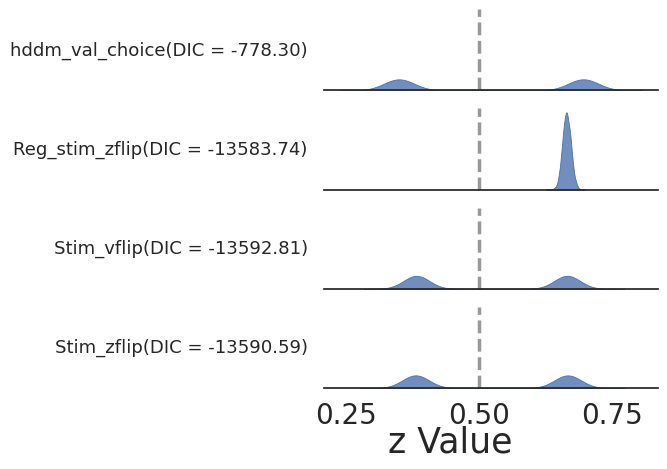

In [7]:
# ================= 图1：单 z 模型（4 个） =================
models_single = {
    'hddm_val_choice(DIC = -778.30)': hddm_val_choice,
    'Stim_vflip(DIC = -13592.81)': Stim_vflip,
    'Stim_zflip(DIC = -13590.59)': Stim_zflip,
    'Reg_stim_zflip(DIC = -13583.74)': Reg_zflip
}

target_param_variants_single = {
    'z': ['z', 'z_Intercept'],
    'z(Good)': ['z(Good)', 'z_trans(Good)', 'z_Intercept(Good)', 'z_Intercept_trans(Good)'],
    'z(Bad)': ['z(Bad)', 'z_trans(Bad)', 'z_Intercept(Bad)', 'z_Intercept_trans(Bad)'],
}


RED_Z = None

def extract_param_stats(model_obj, model_name, dic_value, target_param_variants):
    try:
        stats = model_obj.gen_stats()
    except Exception:
        return pd.DataFrame()
    all_names = stats.index.tolist()
    rows = []
    for display_name, variants in target_param_variants.items():
        raw_name = next((v for v in variants if v in all_names), None)
        if raw_name is None:
            continue
        r = stats.loc[raw_name]
        rows.append({
            'Model': model_name,
            'Parameter': display_name,
            'mean': r['mean'],
            'std': (r['97.5q'] - r['2.5q']) / (2 * 1.96),
            'DIC': dic_value,
        })
    return pd.DataFrame(rows)

all_stats = []
for name, obj in models_single.items():
    dic = getattr(obj, 'dic', None)
    s = extract_param_stats(obj, name, dic, target_param_variants_single)
    if not s.empty:
        all_stats.append(s)
        print(f"{name}: matched")
    else:
        print(f"{name}: NO z matched —— 检查参数名")

df_stats_all = pd.concat(all_stats, ignore_index=True)

np.random.seed(42)
samples_list = []
for _, r in df_stats_all.iterrows():
    samples_list.append(pd.DataFrame({
        'Model': r['Model'], 'Parameter': r['Parameter'],
        'value': np.random.normal(r['mean'], r['std'], 5000), 'DIC': r['DIC']}))
df_samples = pd.concat(samples_list, ignore_index=True)

model_order = (df_samples[['Model', 'DIC']].drop_duplicates()
                 .sort_values('DIC', ascending=False)['Model'].tolist())
df_samples['Model'] = pd.Categorical(df_samples['Model'], categories=model_order, ordered=True)

sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})
g = sns.FacetGrid(df_samples, row='Model', aspect=6, height=1.2, sharex=True, sharey=True)
g.map_dataframe(sns.kdeplot, x='value', fill=True, alpha=0.8, linewidth=0.6)
g.set_titles("")
g.set_axis_labels("", "")
g.set(yticks=[])
g.despine(left=True)
plt.subplots_adjust(hspace=-0.4)

for ax in g.axes.flat:
    ax.axvline(0.5, color='gray', linestyle='--', linewidth=2.5, alpha=0.8)          # 无偏
    if RED_Z is not None:
        ax.axvline(RED_Z, color='crimson', linestyle='--', linewidth=2.0, alpha=0.9)  # 原文献
    ax.tick_params(axis='x', labelsize=20)

for ax, mn in zip(g.axes[:, 0], model_order):
    ax.text(-0.05, 0.5, mn, transform=ax.transAxes, ha='right', va='center', fontsize=13)

g.fig.text(0.6, 0.02, 'z Value', fontsize=25)
plt.tight_layout(rect=[0.03, 0.03, 1, 0.98])
plt.savefig('Fig/ridge_single_z.svg', format='svg', bbox_inches='tight')
plt.show()

hddm_val_acc(DIC = -13593.33): matched
Reg_val_acc(DIC = -13590.09): matched
Reg_val_choice(DIC = -778.39): matched
Reg_stim_vflip_coef(DIC = -13597.51): matched
Reg_stim_vflip_link(DIC = -13590.84): matched


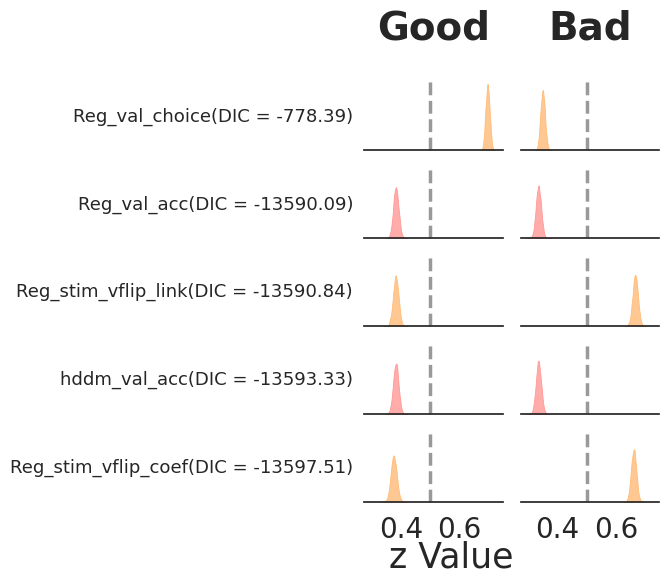

In [9]:
#图2（分 Self/Other 的 5 个模型，两列）——extract_param_stats 已经定义过，直接复用：

# ================= 图2：分 Self/Other 模型（5 个） =================
models_split = {
    'hddm_val_acc(DIC = -13593.33)': hddm_val_acc,
    'Reg_val_acc(DIC = -13590.09)': Reg_val_acc,
    'Reg_val_choice(DIC = -778.39)': Reg_val_choice,
    'Reg_stim_vflip_coef(DIC = -13597.51)': Reg_vflip_coef,
    'Reg_stim_vflip_link(DIC = -13590.84)': Reg_vflip_link,
}

target_param_variants_split = {
    'z': ['z', 'z_Intercept'],
    'z(Good)': ['z(Good)', 'z_trans(Good)', 'z_Intercept(Good)', 'z_Intercept_trans(Good)'],
    'z(Bad)': ['z(Bad)', 'z_trans(Bad)', 'z_Intercept(Bad)', 'z_Intercept_trans(Bad)'],
}

all_stats = []
for name, obj in models_split.items():
    dic = getattr(obj, 'dic', None)
    s = extract_param_stats(obj, name, dic, target_param_variants_split)
    if not s.empty:
        all_stats.append(s)
        print(f"{name}: matched")
    else:
        print(f"{name}: NO z matched —— 检查参数名")

df_stats_all = pd.concat(all_stats, ignore_index=True)

np.random.seed(42)
samples_list = []
for _, r in df_stats_all.iterrows():
    samples_list.append(pd.DataFrame({
        'Model': r['Model'], 'Parameter': r['Parameter'],
        'value': np.random.normal(r['mean'], r['std'], 5000), 'DIC': r['DIC']}))
df_samples = pd.concat(samples_list, ignore_index=True)

model_order = (df_samples[['Model', 'DIC']].drop_duplicates()
                .sort_values('DIC', ascending=False)['Model'].tolist())
df_samples['Model'] = pd.Categorical(df_samples['Model'], categories=model_order, ordered=True)

def get_model_type(name):
    base = name.split('\n')[0]
    return 'choice' if ('choice' in base or 'vflip' in base) else 'acc'
df_samples['Model_Type'] = df_samples['Model'].apply(get_model_type)

TARGET_PARAMS = ['z(Good)', 'z(Bad)']
df_plot = df_samples[df_samples['Parameter'].isin(TARGET_PARAMS)].copy()
df_plot['Parameter'] = pd.Categorical(df_plot['Parameter'], categories=TARGET_PARAMS, ordered=True)

palette = {'acc': '#ff9896', 'choice': '#ffbb78'}

sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})
g = sns.FacetGrid(df_plot, row='Model', col='Parameter', hue='Model_Type',
                    palette=palette, aspect=3, height=1.2, sharex=True, sharey=True)
g.map_dataframe(sns.kdeplot, x='value', fill=True, alpha=0.8, linewidth=0.6)
g.set_titles("")
g.set_axis_labels("", "")
g.set(yticks=[])
g.despine(left=True)
plt.subplots_adjust(hspace=-0.4)

for ax in g.axes.flat:
    ax.axvline(0.5, color='gray', linestyle='--', linewidth=2.5, alpha=0.8)
    ax.tick_params(axis='x', labelsize=20)

for ax, t in zip(g.axes[0], ['Good', 'Bad']):
    ax.set_title(t, fontsize=28, fontweight='bold', pad=30)

for ax, mn in zip(g.axes[:, 0], model_order):
    ax.text(-0.08, 0.5, mn, transform=ax.transAxes, ha='right', va='center', fontsize=13)

g.fig.text(0.6, 0.02, 'z Value', fontsize=25)
plt.tight_layout(rect=[0.03, 0.03, 1, 0.98])
plt.savefig('Fig/ridge_split_z.svg', format='svg', bbox_inches='tight')
plt.show()

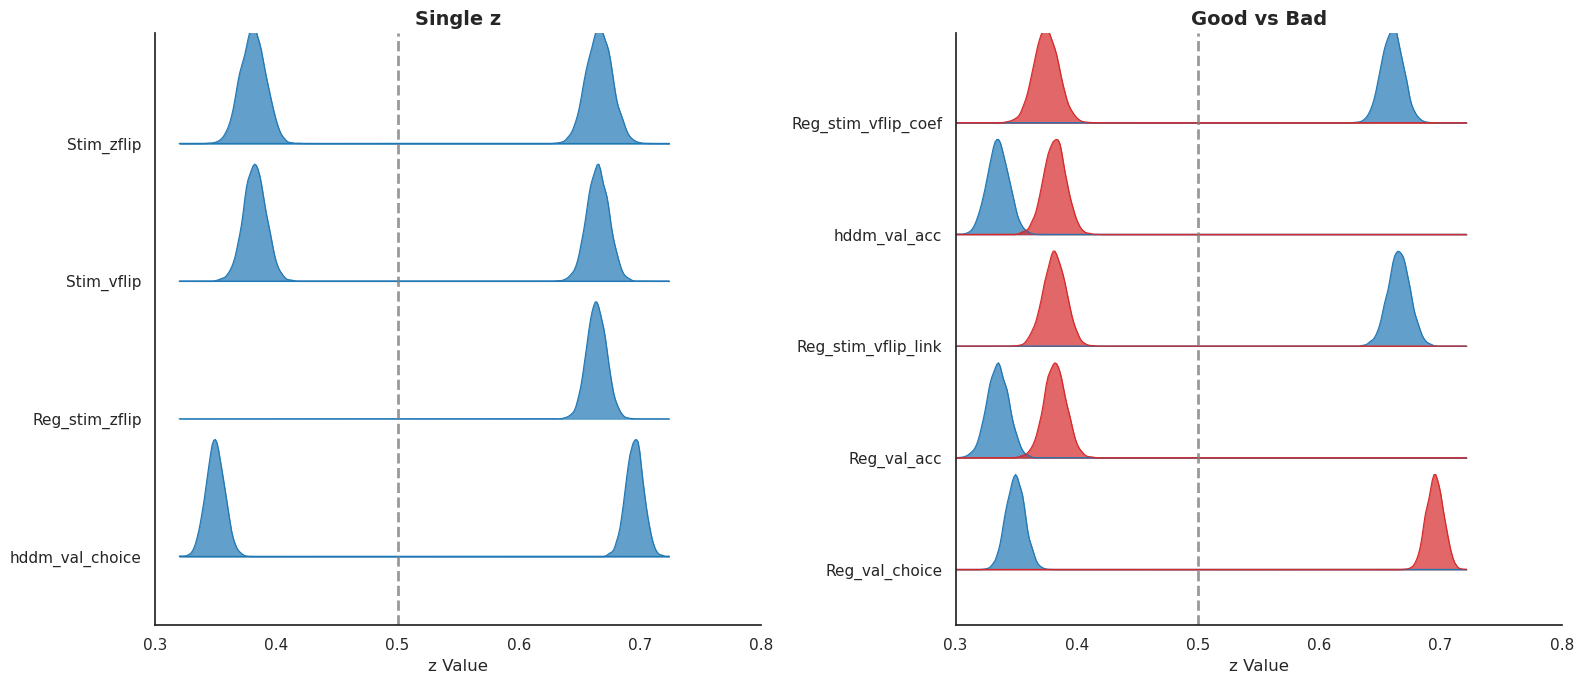

In [10]:
from scipy.stats import gaussian_kde

# ---- 1. 重算两份 samples（模型不重 fit，秒级） ----
# 复用前面 cell 已定义的 models_single / models_split / extract_param_stats / target_param_variants_*
def make_samples(models, variants):
    all_stats = []
    for name, obj in models.items():
        dic = getattr(obj, 'dic', None)
        s = extract_param_stats(obj, name, dic, variants)
        if not s.empty:
            all_stats.append(s)
    df_stats = pd.concat(all_stats, ignore_index=True)
    np.random.seed(42)
    out = []
    for _, r in df_stats.iterrows():
        out.append(pd.DataFrame({
            'Model': r['Model'], 'Parameter': r['Parameter'],
            'value': np.random.normal(r['mean'], r['std'], 5000), 'DIC': r['DIC']}))
    df = pd.concat(out, ignore_index=True)
    order = df[['Model', 'DIC']].drop_duplicates().sort_values('DIC', ascending=False)['Model'].tolist()
    return df, order

df_single, order_single = make_samples(models_single, target_param_variants_single)
df_split,  order_split  = make_samples(models_split,  target_param_variants_split)

# ---- 2. 画合并图 ----
def draw_ridge(ax, df, order, param_colors=None):
    xg = np.linspace(df['value'].min(), df['value'].max(), 300)
    for i, g in enumerate(order):
        sub = df[df['Model'] == g]
        for p, grp in sub.groupby('Parameter'):
            kde = gaussian_kde(grp['value'].values)
            y = kde(xg)
            y = y / y.max() * 0.85
            c = param_colors.get(p, '#1f77b4') if param_colors else '#1f77b4'
            ax.fill_between(xg, i, i + y, alpha=0.7, color=c, linewidth=0.6)
            ax.plot(xg, i + y, color=c, linewidth=0.8)
    ax.set_yticks(range(len(order)))
    ax.set_yticklabels([o.split('(DIC')[0].strip() for o in order], fontsize=11)
    ax.set_ylim(-0.5, len(order) - 0.2)
    if df['value'].min() <= 0.5 <= df['value'].max():
        ax.axvline(0.5, color='gray', linestyle='--', linewidth=2, alpha=0.8)
    for s in ['top', 'right']:
        ax.spines[s].set_visible(False)
    # ---- x 轴刻度：0.1 间隔，自动对齐数据范围 ----
    lo = np.floor(df['value'].min() * 10) / 10
    hi = np.ceil(df['value'].max() * 10) / 10
    ax.set_xticks(np.arange(lo, hi + 0.05, 0.1))
    ax.set_xlim(lo, hi)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

draw_ridge(ax1, df_single, order_single)                                          # 左：单 z
draw_ridge(ax2, df_split, order_split,
            param_colors={'z(Good)': '#d62728', 'z(Bad)': '#1f77b4'})           # 右：good=红 / bad=蓝

ax1.set_title('Single z', fontsize=14, fontweight='bold')
ax2.set_title('Good vs Bad', fontsize=14, fontweight='bold')
ax1.set_xlabel('z Value', fontsize=12)
ax2.set_xlabel('z Value', fontsize=12)
plt.tight_layout()
plt.savefig('Fig/ridge_combined.svg', format='svg', bbox_inches='tight')
plt.show()